# Logistic Regression: From First Principles
- Kushal Kharel

Despite its name, logistic regression is a probabilistic classification model, not a regression model in the usual sense. In linear regression, we predict a continuous value $y = mx + b$. However, for classification, we need a probability between 0 and 1. To acheive this, we take the linear output and pass it through an activation function called the *Sigmoid (or Logistic) function*.

The sigmoid function $\sigma(z)$ maps any real-valued number into the range $(0,1)$.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

We can see in the equation above that when $z$ is large and positive, $\sigma(z)$ approches 1 and when it is large and negative, it approches 0. This makes the sigmoid a natural choice for modeling probabilities.

We define our hypothesis $h_{\theta} (x)$ as:

$$
h_{\theta} (x) = \sigma(\theta^Tx) = \frac{1}{1 + e^{-\theta^Tx}}
$$

where:
- $x$ is the input vector
- $\theta$ is the weight vector (parameters)
- $\theta^Tx$ is the dot product (logit)


This definition directly indues the conditional probability model:


$$
P(y = 1 | x;\theta) = h_{\theta} (x)
$$

$$
P(y = 0 | x;\theta) = 1 - h_{\theta} (x)
$$

Typically, we use a threshold of 0.5. That is predict $y = 1$ if $h_{\theta} (x) ≥ 0.5$ which happens when $\theta^Tx \ge 0$ and predict $y=0$ if $h_{\theta} (x) < 0.5$.

We can write the above more compactly as follows:

$$
p(y|x;\theta) = (h_{\theta} (x))^y(1-h_{\theta} (x))^{1-y}
$$

We cannot use the Mean Squared Error (MSE) for logistic regression because the sigmoid function makes the MSE cost function non-convex, leading to many local minima. Instead, we use Log Loss (Binary Cross-Entropy).


Assuming that the $n$ training examples were generated independently, we write the likelihood of parameters for a bernoulli distribution (since y is 0 or 1) as:

$$
L(\theta) = p(\vec y|X;\theta) = \prod_{i=1}^n p(y_i | x_i;\theta) = \prod_{i=1}^n ( h_{\theta} (x_i))^{y_i} ( 1 - h_{\theta} (x))^{1 - y_i}
$$

The likelihood $L(\theta)$ represents the probability of observing actual data given a set of parameters $\theta$.

We know that it is easier to maximize the log likelihood because of the property of logs. We laos know that maximizing the product of many small probabilities is computationally difficult and prone to numerical underflow. By taking the natural logarithm, we turn the products into sums. Applying log on both sides we get,

$$
l(\theta) = \log L(\theta) = \sum_{i=1}^n [y_i\log ( h_{\theta} (x_i)) + (1-y_i) \log ( 1 - h_{\theta} (x_i))]
$$

Note if $y = 1$ and $ h_{\theta} (x) \to 1$ the cost is near zero and if $y=1$ and $ h_{\theta} (x) \to 0$ the cost approches $\infty$.

In optimization theory, most algorithms like  gradient descent are designed to find the minimum of a function. To use them, we define the cost function $J(\theta)$ as the Negative Log-Likelihood (NLL).

$$
J(\theta) = -l(\theta)
$$

Note: The $\theta$ that maximizes the log-likelihood is the exact same $\theta$ that minimizes the negative log-likelihood.

How do we maximize the likelihood? We can use the gradient ascent since we are maximizng the funtion. To derive the gradient of the log-likelihood with respect to a specific parameter $\theta_j$, we use the chain rule of the calculus. Before we differentiate the sum, let's identify the derivative of our activation function, the sigmoid below:

$$
h_{\theta}(x) = \sigma(\theta^Tx) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
\sigma'(z) = \frac{d}{dz} \frac{1}{1 + e^{-z}} = \frac{1}{(1 + e^{-z})^2}(e^{-z}) = \big(\frac{1}{1 + e^{-z}}\big)\Big(1 - \frac{1}{1 + e^{-z}}\Big)
$$

Hence,
$$
 \sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

Now back to the differention:

$$
\frac{\partial}{\partial \theta_j}l(\theta) = \Big( y \frac{1}{\sigma(\theta^Tx)} - (1-y) \frac{1}{1 - \sigma(\theta^Tx)} \Big) \frac{\partial}{\partial \theta_j}\sigma(\theta^Tx)
$$

$$
= \Big( y \frac{1}{\sigma(\theta^Tx)} - (1-y) \frac{1}{1 - \sigma(\theta^Tx)} \Big)\sigma(\theta^Tx)(1 -\sigma(\theta^Tx))\frac{\partial}{\partial \theta_j}(\theta^Tx)
$$

$$
= (y(1 - \sigma(\theta^Tx)) - (1-y)\sigma(\theta^Tx))x_j
$$

Hence,

$$
\frac{\partial}{\partial \theta_j}l(\theta)  = (y - h_{\theta}(x))x_j
$$

This represents the error $(y_i - h_{\theta}(x_i))$ multiplied by the feature value $x_j$. Because this is the derivative of the likelihood (not the cost), a positive gradient tells us to increase $\theta_j$ to increase the likelihood.

For implementation, we usually write this for the entire weight vector $\theta$ in vectorized form:

$$
\nabla_{\theta}l(\theta) = X^T(y-h_{\theta}(X))
$$

In optimization, to reach the maximum of a function, we take small steps proportional to the gradient. The update rule is defined as:

$$
\theta_{new} = \theta_{old} + \alpha \nabla_{\theta}l(\theta)
$$

Substituting our specific gradient into this formula, we get:

$$
\theta := \theta + \alpha \sum_{i=1}^n (y_i - h_{\theta}(x))x_j
$$

where:
- $\theta$ is the weight vector we are trying to optimize
- $\alpha$ is the learning rate, a small positive scalar that controls the size of each step
- $y_i - h_{\theta}(x)$ is the error term. It is the difference between the actual label and the predicted probability
- $x_j$ is the input features, which determine the direction of the update for each specific weight

Another alternative to gradient ascent is the Newton's method which we will not discuss here. It will be discussed in another article. While gradient ascent takes many small steps, Newton's method uses second derivative (Hessian matrix $H$) to find the maximum more aggresively. The update rule for Newton's method is:

$$
\theta := \theta - H^{-1} \nabla_{\theta}l(\theta)
$$

Because it uses curvature information, Newton's method oftern converges in far fewer iterations than standard gradient ascent,  though calculating the inverse of the Hessian can be computationally expensive for very large datasets.

We will not be talking about regularization steps to avoid overfitting in this article. We are strictly talking the math behind logistic regression. Now, let's move on th builiding a LogisticRegression with Gradient Ascent class. We will use vectorized operations for efficieny.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
class LogisticRegressionGA:
  def __init__(self, learning_rate = 0.01, iterations = 1000):
    self.learning_rate = learning_rate
    self.iterations = iterations
    self.theta = None
    self.likelihood_history = []

  def _sigmoid(self, z):
    """
    Numerically stable sigmoid function
    """
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

  def fit(self, X, y):
    # Add intercept (bias) tern to X
    # which allows us to treat theta_zero as a weight
    # for a feature of 1s
    n_samples, n_features = X.shape
    X_intercept = np.hstack([np.ones((n_samples, 1)), X])

    # Initialize weights (thetas) to zeros
    self.theta = np.zeros(n_features + 1)

    # optimization loop
    for i in range(self.iterations):
      # calculate the linear combination (z = X * theta)
      z = X_intercept @ self.theta

      # calcualte predictions (h_theta)
      h = self._sigmoid(z)

      # calculate Gradient (ascent):
      # grad = X^T * (y - h) pointing towards maximum likelihood
      gradient = (X_intercept.T @ (y - h)) / n_samples

      # update weights: theta_new = theta_old + alpha * gradient
      self.theta += self.learning_rate * gradient

      # track log-likelihood for convergence monitoring: (we are using mean instead of sum)
      # l(theta) = mean(y*log(h) + (1-y)*log(1-h)) instead of sum(y*log(h) + (1-y)*log(1-h))
      ll = np.mean(y*np.log(h + 1e-15) + (1-y)*np.log(1 - h + 1e-15))
      self.likelihood_history.append(ll)

  def predict_proba(self, X):
    X_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
    return self._sigmoid(X_intercept @ self.theta)

  def predict(self, X, threshold=0.5):
    return (self.predict_proba(X) >= threshold).astype(int)

In [ ]:
# Generate synthetic dataset

X, y = make_classification(n_samples = 10000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=42)


In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# preprocess the data, standardization is vital for gradient based methods (see it for yourself)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# training the model

model = LogisticRegressionGA(learning_rate=0.02, iterations = 50000)
model.fit(X_train, y_train)

In [ ]:

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 98.25%


In [ ]:
# Visualize the convergence and decision boundaries

def plot_results(X, y, model):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
  # log-likelihood trend
  ax1.plot(model.likelihood_history)
  ax1.set_title("Log-likelihood (should increase)")
  ax1.set_xlabel("Iteration")
  ax1.set_ylabel("Log-likelihood")

  # Decision Boundary
  x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
  y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  ax2.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
  ax2.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='RdBu')
  ax2.set_title(f"Decision Boundary (Acc: {np.mean(model.predict(X)==y)*100:.1f}%)")
  plt.show()

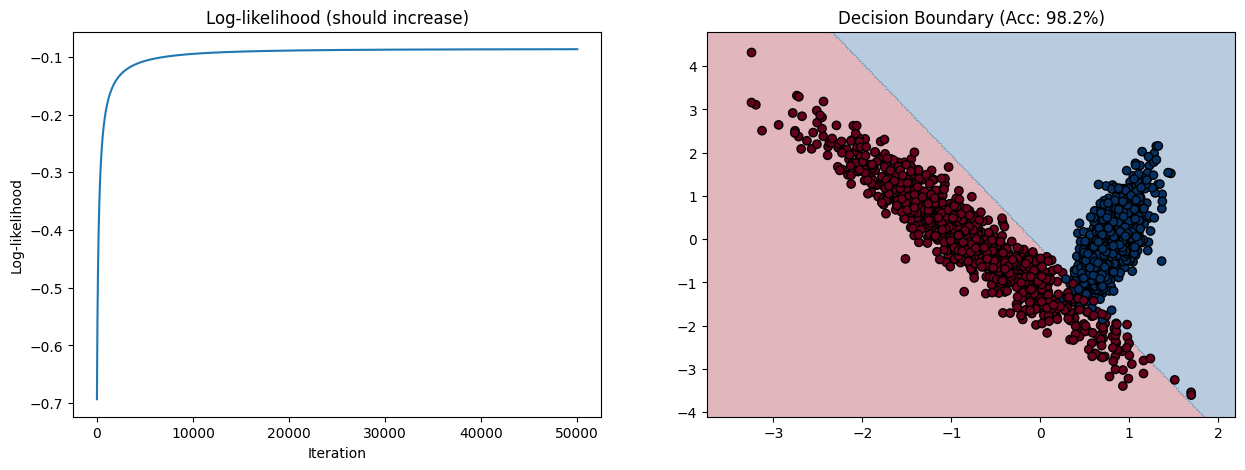

In [ ]:
plot_results(X_test, y_test, model)

Accuracy alone is insufficient for probabilistic classifiers. We additionally evaluate:
- ROC-AUC (ranking performance)
- Brier Score (probability calibration)

In [ ]:
from sklearn.metrics import log_loss, roc_auc_score

probs = model.predict_proba(X_test)
auc = roc_auc_score(y_test, probs)

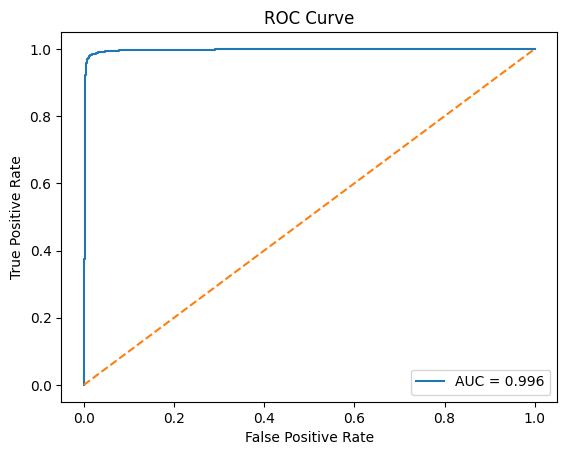

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

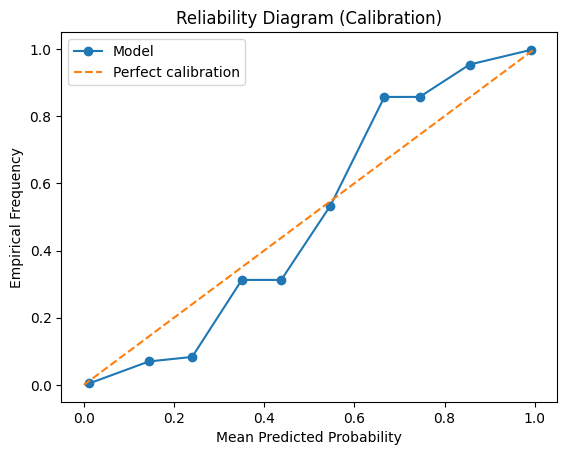

In [ ]:
# brier score: calibration (reliabbility) diagrm
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Empirical Frequency")
plt.title("Reliability Diagram (Calibration)")
plt.legend()
plt.show()

Calibration measures whether the predicted probabilities correspond to empirical frequencies. We asses calibration using the Expected Calibration Error

In [ ]:
# optional: Expected Calibration Error (ECE)

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(probs, bins) - 1

ece = 0
for i in range(10):
  mask = bin_ids == i
  if np.any(mask):
    ece += np.abs(probs[mask].mean() - y_test[mask].mean()) * mask.mean()
print(f"ECE: {ece:.4f}")

ECE: 0.0154


An ECE value close to zero indicates well-calibrated probabilities. In our experiment, we observe ECE close to zero which is consistent with theoretical expectations for logistic regression under correct specification.

In [ ]:
# checking with sklearn Logistic Regression Model
from sklearn.linear_model import LogisticRegression

sk = LogisticRegression(solver="lbfgs", penalty=None, fit_intercept=True)
sk.fit(X_train, y_train)

LogisticRegression(penalty=None)

In [ ]:
sk.intercept_, sk.coef_.ravel()

(array([0.81372694]), array([7.83845619, 3.73305109]))

In [ ]:
model.theta

array([0.69315802, 7.42142297, 3.48763799])

In [ ]:
np.allclose(np.r_[sk.intercept_, sk.coef_.ravel()], model.theta, atol=1e-3)

False

In [ ]:
def mean_log_likelihood(theta, X, y):
    z = X @ theta
    h = 1 / (1 + np.exp(-np.clip(z, -30, 30)))
    h = np.clip(h, 1e-12, 1 - 1e-12)
    return np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

In [ ]:
Xb_test = np.c_[np.ones(X_test.shape[0]), X_test]
ll_sklearn = mean_log_likelihood(np.r_[sk.intercept_, sk.coef_.ravel()],Xb_test, y_test)
ll_model = mean_log_likelihood(model.theta, Xb_test, y_test)

In [ ]:
ll_gap = ll_sklearn - ll_model
ll_gap

np.float64(0.001350549400602169)

In [ ]:
np.max(np.abs(sk.predict_proba(X_test)[:,1] - model.predict_proba(X_test)))

np.float64(0.021992547283275432)

Although both implementations optimize the same (unregularized) log-likelihood, exact parameter agreement is not guaranteed. For (nearly) linearly separable data, the logistic regression log-likelihood increases monotonically as the norm of the parameter vector grows, and the maximum likelihood estimator does not exist as a finite point. As a result, different optimization algorithms may terminate at different parameter magnitudes while achieving very similar likelihood values and predicted probabilities. Our gradient-ascent implementation therefore converges in likelihood and nearly in probability space, but not necessarily in parameter space, which explains why direct coefficient comparison via np.allclose fails despite comparable predictive and calibration performance.

Common pitfalls:

- Learning Rate ($\alpha$) Sensitivity: If $\alpha$ is too high, the likelihood will fluctuate or diverge. If too low, it will take forever to converge.
- The Intercept Term: Forgetting to add a column of ones to input data $(X)$ is the most common error. Without it, decision boundary is forced to pass through the origin.
- Numerical Underflow: We add a tiny constant inside the log function to prevent log(0), which returns negative infinity and crashes the optimization.
- Data Scaling: Logistic regression relies on the dot product $\theta^Tx$. If one feature has range of $[0,1]$ and another has $[0,1000]$, the gradient will be dominated by the larger feature, making the model unstable.


## Moving beyond Binary: Softmax Regression

When we move from 2 classes to $K$ classes, Logistic Regression evolves into softmax regression (or multinomial logistic regression).

Instead of a single sigmoid function that outputs a scalar between 0 and 1, we use the softmax function. It takes a vector of scores $z$ and normalizes them into a probability distribution where all values sum to 1.

*Key Difference*

- The Activation: For class $k$, the probability is:

$$
P(y=k|x) = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}
$$

- The Loss: We replace binary cross entropy with categorical cross entropy
- The output: The model now outputs a vector of $K$ probabilities rather than a single value.



Explore softmax and $L_2$ regularization (Weight Decay) to prevent overfitting on your own. This wraps us the short study on logistic regression.